# Лабораторная 1 – Гусев Иван

In [1]:
# Внешние импорты
import os
import re
import string
import random
import statistics
import pymorphy3
# import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Внутренние импорты
from writers_and_readers import fb2reader, txt_reader, epub_reader

## Первая часть

### Объединяем .csv

In [2]:
negative = pd.read_csv("negative.csv", header=None, sep=';')
positive = pd.read_csv("positive.csv", header=None, sep=';')
dataset = pd.concat([negative, positive])
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


### Удаляем стоп-слова

In [3]:
morph = pymorphy3.MorphAnalyzer()

In [4]:
stop_words = set(stopwords.words("russian"))
stop_words.remove("хорошо")

print(stop_words)

{'из', 'тот', 'тут', 'там', 'можно', 'том', 'без', 'еще', 'себя', 'всего', 'ну', 'так', 'же', 'даже', 'вам', 'была', 'эти', 'уже', 'ей', 'всех', 'от', 'будет', 'после', 'то', 'раз', 'в', 'с', 'бы', 'нет', 'такой', 'только', 'этой', 'ничего', 'или', 'ты', 'есть', 'у', 'они', 'и', 'этот', 'ним', 'наконец', 'вдруг', 'об', 'я', 'на', 'при', 'мой', 'о', 'него', 'но', 'нельзя', 'сам', 'ней', 'чтоб', 'нас', 'может', 'про', 'потому', 'потом', 'вот', 'всегда', 'никогда', 'когда', 'для', 'что', 'ведь', 'чтобы', 'хоть', 'между', 'лучше', 'конечно', 'тебя', 'три', 'чем', 'к', 'чего', 'какая', 'ни', 'был', 'свою', 'почти', 'этом', 'уж', 'да', 'было', 'более', 'больше', 'здесь', 'где', 'все', 'совсем', 'во', 'со', 'их', 'тем', 'куда', 'иногда', 'ее', 'им', 'как', 'ли', 'разве', 'чуть', 'себе', 'за', 'опять', 'всю', 'вы', 'быть', 'впрочем', 'по', 'если', 'этого', 'много', 'а', 'над', 'какой', 'она', 'меня', 'теперь', 'через', 'мне', 'вас', 'его', 'того', 'нее', 'другой', 'два', 'мы', 'будто', 'надо',

In [5]:
def text_preprocess(text: str) -> str:
    """
    Функция предобработки текст: приведение к нижнему регистру, токенизация, лемматизация
    """
    normalized_text = text
    normalized_text = normalized_text.lower()
    normalized_text = re.sub(r"\n+?", "\n", normalized_text)
    normalized_text = [word for word in normalized_text.split() if word not in stop_words]
    normalized_text = [morph.parse(word)[0].normal_form for word in normalized_text]
    normalized_text = " ".join(normalized_text)
    normalized_text = normalized_text.translate(str.maketrans('', '', string.punctuation))
    # Удаляем все ссылки из текстов
    normalized_text = re.sub(r"https?:\/\/.*?[\s+]", "", normalized_text)
    # normalized_text = re.sub(r"[^А-Яа-яЁё\s]", "", normalized_text)
    return normalized_text

In [6]:
# Применяем предобработку текста ко всему датасету
dataset.iloc[:, 3] = dataset.iloc[:, 3].apply(text_preprocess)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,408906762813579264,1386325944,dugarchikbellko,работа полный пиддес каждый закрытие месяца с...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,коллега сидеть рубиться urban terror изза долб...,-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,elina4post говорить обещаной год ждут,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,желать хороший полёт удачный посадкить быть оч...,-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,обновить какойто леший surf работать простоплеер,-1,0,0,0,35,17,34,0


### Делаем sentiment-анализ

In [7]:
# Считываем LinisCrowd 2015
sentiment_dataset = pd.read_csv("words_all_full_rating.csv", encoding="cp1251", sep=";", index_col="Words")
sentiment_dataset.head()

,mean,dispersion,average rate,Unnamed: 4
Words,,,,
аборигенный,"-0,25","0,433012701892219",0,NaN
аборт,-1,"0,816496580927726",-1,NaN
абрамович,0,0,0,NaN
абсолютный,"0,333333333333333","0,471404520791032",0,NaN
абстрактный,"-0,111111111111111","0,87488976377909",0,NaN


In [8]:
def sentiment_analysis(text: str, sentiment_df: pd.DataFrame) -> list:
    """
    Функция, которая преобразует текст в вектор из 
    среднего, максимального, минимального, 
    суммарного значения и количества положительных и отрицательных значений
    """

    METRICS_AMOUNT = 6
    
    def count_metrics(embedded_sentence):
        """
        Функция, которая считает по векторам предложений метрики
        (среднее, максимальное, минимальное, суммарное значение и количество положительных и отрицательных значений)
        """
        return [
            statistics.mean(embedded_sentence), max(embedded_sentence), 
            min(embedded_sentence), sum(embedded_sentence), 
            embedded_sentence.count(1), embedded_sentence.count(-1)
            ]
    

    processed_text = text.split()
    embedded_text = []
    for word in processed_text:
        try:
            word_sentiment = (sentiment_df.loc[word]["average rate"])
            embedded_text.append(float(word_sentiment))
        except KeyError:
            pass
    # Если ни для одного слова не нашлось значения, записываем ноль
    if len(embedded_text) == 0:
        return [0.0] * METRICS_AMOUNT
    return count_metrics(embedded_text)

In [9]:
# Получаем лейблы X – тексты, преобразованные в вектора
sentiment_X = list(map(lambda text: sentiment_analysis(text, sentiment_dataset), dataset.iloc[:, 3].to_list()))
# Получаем лейблы Y – значения -1 и 1 из колонки 4
Y = dataset.iloc[:, 4].to_list()

len(sentiment_X), len(Y)

(226834, 226834)

### Обучаем классификатор на векторе из признаков сентимента

In [10]:
# Для XGBoost нужны лейблы 0/1, так что переформатируем наш список с лейблами на детектор негативных твитов
Y = [1 if label == -1 else 0 for label in Y]

In [11]:
sentiment_train, sentiment_test, sentiment_labels_train, sentiment_labels_test = train_test_split(sentiment_X, Y, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(sentiment_train, sentiment_labels_train)
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300}


In [12]:
pred = grid.best_estimator_.predict(sentiment_test)
print(classification_report(sentiment_labels_test, pred))

              precision    recall  f1-score   support

           0       0.68      0.20      0.31     23069
           1       0.52      0.90      0.66     22298

    accuracy                           0.54     45367
   macro avg       0.60      0.55      0.48     45367
weighted avg       0.60      0.54      0.48     45367



### Извлекаем морфологические признаки

In [13]:
POS_TAGS = [
    'NOUN', 'VERB', 'ADJF', 'ADJS', 'COMP', 'INFN', 'PRTF', 'PRTS',
    'GRND', 'NUMR', 'ADVB', 'NPRO', 'PRED', 'PREP', 'CONJ', 'PRCL', 'INTJ'
]

def get_relative_POS(text):
    # Если на входе не строка, возвращаем нули
    if not isinstance(text, str):
        return [0.0] * len(POS_TAGS)
    try:
        # Разбор и извлечение POS
        sentence_POS = [morph.parse(word)[0].tag.POS for word in text.split()]
        sentence_POS = [POS for POS in sentence_POS if POS]
        
        if not sentence_POS:
            return [0.0] * len(POS_TAGS)
        
        # Подсчёт относительных частот
        sentence_len = len(sentence_POS)
        pos_freqs = {pos: sentence_POS.count(pos) / sentence_len for pos in POS_TAGS}
        
        # Возвращаем вектор в порядке POS_TAGS
        return [pos_freqs[pos] for pos in POS_TAGS]
    
    except Exception:
        return [0.0] * len(POS_TAGS)

In [14]:
POS_frequency = dataset.iloc[:, 3].apply(get_relative_POS).to_list()

### Обучаем классификатор на частиречной относительной частоте

In [15]:
POS_train, POS_test, POS_labels_train, POS_labels_test = train_test_split(POS_frequency, Y, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(POS_train, POS_labels_train)
print(grid.best_params_)

{'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 400}


In [16]:
pred = grid.best_estimator_.predict(POS_test)
print(classification_report(POS_labels_test, pred))

              precision    recall  f1-score   support

           0       0.57      0.58      0.57     23069
           1       0.56      0.54      0.55     22298

    accuracy                           0.56     45367
   macro avg       0.56      0.56      0.56     45367
weighted avg       0.56      0.56      0.56     45367



### Извлекаем признаки с помощью мешка слов

In [17]:
vectorizer = TfidfVectorizer()
svd = TruncatedSVD(n_components=1000, random_state=42)


corpus = dataset.iloc[:, 3].to_list()
# Извлекаем признаки
X = vectorizer.fit_transform(corpus)
# Сокращает размерность
# TrunkatedSVD оптимизирован под разреженные матрицы, такие как Tf-Idf
X_svd = svd.fit_transform(X)

X_svd[0].shape

(1000,)

In [18]:
X_svd[0]

array([ 2.04130359e-02, -9.82406864e-03, -1.07027693e-02, -6.71350567e-03,
        1.82991786e-03,  7.12516959e-04, -3.16149306e-03, -1.06403422e-02,
       -1.78786825e-03, -2.64097611e-03, -4.78302703e-03, -7.14419656e-04,
       -1.06626484e-03, -2.20465604e-03,  3.06342338e-03, -2.33933341e-03,
        8.02776968e-03, -3.35237029e-03, -5.03409038e-03,  6.35967781e-03,
       -1.02200852e-03, -6.45004623e-05, -1.60426278e-03,  1.04662396e-02,
        1.04403111e-02, -2.69855434e-03, -8.11332676e-03,  1.65983133e-03,
        4.13256239e-03,  1.03253810e-02,  8.51807764e-03,  1.21114095e-02,
        1.39740993e-03,  3.18391606e-03, -8.01555584e-03, -2.32981648e-03,
        9.96686823e-04,  2.09814684e-03, -8.73023655e-03, -5.18775694e-03,
        5.24413348e-03, -4.66612868e-03, -2.83213052e-03, -5.68213928e-03,
        5.30272556e-03,  1.41568449e-02,  1.15253148e-03, -1.84562947e-02,
        8.49204288e-03, -1.71165000e-04,  2.29054547e-04, -2.84901154e-03,
        8.80797629e-03,  

### Обучаем классификатор на мешке слов

In [20]:
X_svd_train, X_svd_test, Y_labels_train, Y_labels_test = train_test_split(X_svd, Y, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.3],
    "min_child_weight": [3]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid.fit(X_svd_train, Y_labels_train)
print(grid.best_params_)

{'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 400}


In [21]:
pred = grid.best_estimator_.predict(X_svd_test)
print(classification_report(Y_labels_test, pred))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71     23069
           1       0.71      0.67      0.69     22298

    accuracy                           0.70     45367
   macro avg       0.70      0.70      0.70     45367
weighted avg       0.70      0.70      0.70     45367



## Вторая часть

### Word2vec

Берем корпус литературных текстов и объединяем их в список из списков (по предложениям): так нужно для word2vec

In [22]:
# Для word2vec не используем nltk-библиотеку со стоп-словами, а делаем своё
# Нам нужно сохранить каркас языка, но удалить шум: слова-паразиты, вводные слова
# nltk выбрасвает много полезного для wav2vec: местоимения, союзы

stopwords = {
    # Разговорный шум
    "вот", "ну", "ага", "ладно", "типа", "короче",
    "вообще", "просто", "как бы", "вроде",
    "кажется", "разве", "кстати", "значит",
    # Усилители / модальные
    "очень", "реально", "буквально", "фактически",
    "примерно", "почти", "вполне", "совсем",
    # Вводные и связки
    "например", "итак", "итого", "впрочем",
    "собственно", "действительно", "между прочим",
    # Реплики речи
    "сказал", "сказала", "сказали",
    "говорил", "говорила", "говорили",
    "спросил", "спросила", "ответил", "ответила",
    # Временные маркеры без смысла
    "сейчас", "теперь", "потом", "вдруг",
    "тогда", "уже", "ещё", "еще",
    # Слова-паразиты
    "ну вот", "давай", "типа того",
    "чё", "че", "щас",
    # Формальные
    "ибо", "пускай", "пусть"
}

In [23]:
def word2vec_preprocess(text):
    normalized_text = text.lower()
    # Удаляем все ссылки из текстов
    normalized_text = re.sub(r"https?:\/\/.*?[\s+]", "", normalized_text)
    # normalized_text = re.sub(r"[^А-Яа-яЁё\s]", "", normalized_text)
    normalized_text = re.sub(r"\n+?", "\n", normalized_text)
    normalized_text = normalized_text.split(".")

    preprocessed_text = []
    for sentence in normalized_text:
        sentence_normalized = sentence.translate(str.maketrans('', '', string.punctuation))
        sentence_normalized = sentence_normalized.split()
        sentence_normalized = [word for word in sentence_normalized if word not in stop_words]
        sentence_normalized = [morph.parse(word)[0].normal_form for word in sentence_normalized]
        preprocessed_text.append(sentence_normalized)
        
    return preprocessed_text

In [24]:
def text_fetcher(repo_path: str) -> dict:
    litcorpus = []
    for root, _, files in os.walk(repo_path):
        for file in files:
            if file.startswith('.'):
                continue

            full_path = os.path.join(root, file)
            if file.endswith('.fb2'):
                try:
                    text = fb2reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

            elif file.endswith('.txt'):
                try:
                    text = txt_reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

            elif file.endswith('.epub'):
                try:
                    text = epub_reader(full_path)
                    text = word2vec_preprocess(text)
                    litcorpus.extend(text)
                except Exception as e:
                    print(f'An error {e} occurred!')
                    continue

    return litcorpus

In [25]:
literature_dir = "literature"

corpus = text_fetcher(literature_dir)
print(f"Всего {len(corpus)} предложений")

Всего 209372 предложений


In [26]:
words = [item for sublist in corpus for item in sublist]
print(f"Всего {len(words)} слов")

Всего 1932816 слов


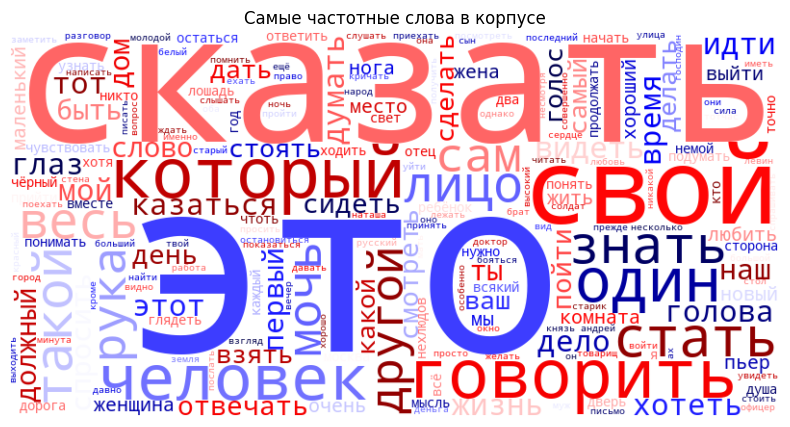

In [27]:
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='seismic').generate(" ".join(words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Самые частотные слова в корпусе")
plt.show()

In [28]:
word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=200,
    window=5,
    min_count=5,
    sg=0,
    alpha=0.025,
    min_alpha = 0.0001,
    epochs=7
)

In [29]:
# Делаем проверку: ищем похожие слова для...
similar_to_man = word2vec_model.wv.most_similar("мужчина", topn=5) if "мужчина" in word2vec_model.wv else None
similar_to_man

[('женщина', 0.8271538019180298),
 ('пожилой', 0.7707713842391968),
 ('девушка', 0.755182147026062),
 ('красивый', 0.6910814046859741),
 ('образовать', 0.688340961933136)]

In [30]:
# Делаем проверку: ищем похожие слова для...
similar_to_woman = word2vec_model.wv.most_similar("женщина", topn=5) if "женщина" in word2vec_model.wv else None
similar_to_woman

[('девушка', 0.8917348384857178),
 ('мужчина', 0.8271538019180298),
 ('человек', 0.6816673874855042),
 ('мальчик', 0.6815813779830933),
 ('девочка', 0.6477497220039368)]

In [31]:
# Делаем проверку: ищем похожие слова для...
similar_to_sky = word2vec_model.wv.most_similar("небо", topn=5) if "небо" in word2vec_model.wv else None
similar_to_sky

[('солнце', 0.906389594078064),
 ('звезда', 0.8769376873970032),
 ('туча', 0.8538169264793396),
 ('луч', 0.8534532785415649),
 ('туман', 0.8511471152305603)]

In [32]:
# Делаем проверку: ищем похожие слова для...
similar_to_horse = word2vec_model.wv.most_similar("конь", topn=5) if "конь" in word2vec_model.wv else None
similar_to_horse

[('сено', 0.814302921295166),
 ('лошадь', 0.8103610277175903),
 ('козак', 0.8080242276191711),
 ('хлопец', 0.7917554974555969),
 ('воз', 0.7906420826911926)]

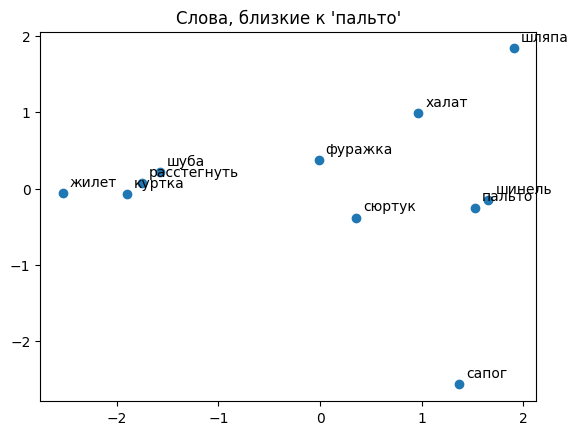

In [33]:
# Берем случайное (или не случайное) слово из словаря
# random_word = random.choice(word2vec_model.wv.index_to_key)
random_word = "пальто"

# Берем 20 близких слов
similar_words = word2vec_model.wv.most_similar(random_word, topn=10)

# Собираем список слов
words = [random_word] + [w for w, _ in similar_words]

# Получаем их векторы
vectors = np.array([word2vec_model.wv[w] for w in words])

# Снижаем размерность до 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure()
plt.scatter(coords[:, 0], coords[:, 1])
for i, word in enumerate(words):
    x, y = coords[i]
    plt.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(f"Слова, близкие к '{random_word}'")
plt.show()

### Получаем вектора word2vec из RuTweetCorp

In [34]:
# Предобрабатываем тексты функцией для word2vec
tweets = list(map(word2vec_preprocess, dataset.iloc[:, 3].to_list()))
tweets_labels = dataset.iloc[:, 4].to_list()

In [35]:
# Получаем для твитов word2vec вектора
tweets_word2vec = []
tweets_word2vec_labels = []

for index, tweet in enumerate(tweets):
    for sentence in tweet:
        sentence_embedding = []
        for word in sentence:
            if word in word2vec_model.wv:
                sentence_embedding.append(word2vec_model.wv[word])

        # Обработка случая, когда ни одного слова не было в твите
        if len(sentence_embedding) > 0:
            # Усредняем вектора в твитах
            sentence_embedding = np.mean(sentence_embedding, axis=0)
            # Добавляем вектор в список и добавляем его label
            tweets_word2vec.append(sentence_embedding)
            tweets_word2vec_labels.append(tweets_labels[index])
        else:
            continue

print(f"Количество твитов ПОСЛЕ w2v: {len(tweets_word2vec)} (количество меток равно {len(tweets_word2vec_labels)}), количество твитов ДО: {len(dataset)}")

Количество твитов ПОСЛЕ w2v: 220941 (количество меток равно 220941), количество твитов ДО: 226834


### Учим сентимент-классификатор на основе полученных векторов и лейблов к ним

In [36]:
# Для XGBoost нужны лейблы 0/1, так что переформатируем наш список с лейблами на детектор негативных твитов
tweets_word2vec_labels = [1 if label == -1 else 0 for label in tweets_word2vec_labels]

In [37]:
print(f"Классы сбалансированы: {tweets_word2vec_labels.count(0)} и {tweets_word2vec_labels.count(1)}")

Классы сбалансированы: 111948 и 108993


In [38]:
W2V_train, W2V_test, W2V_labels_train, W2V_labels_test = train_test_split(tweets_word2vec, tweets_word2vec_labels, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(W2V_train, W2V_labels_train)
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 400}


In [39]:
pred = grid.best_estimator_.predict(W2V_test)
print(classification_report(W2V_labels_test, pred))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66     22588
           1       0.64      0.62      0.63     21601

    accuracy                           0.65     44189
   macro avg       0.65      0.64      0.64     44189
weighted avg       0.65      0.65      0.65     44189



### Учим классификатор word2vec на корпусе RuTweetCorp

In [45]:
# Удаляем лишние вложенные списки, так как в данном случае твит == предложение
tweets = [tweet[0] for tweet in tweets]
tweets

[['работа',
  'полный',
  'пиддес',
  'каждый',
  'закрытие',
  'месяц',
  'свихнуться',
  'd'],
 ['коллега',
  'сидеть',
  'рубиться',
  'urban',
  'terror',
  'изз',
  'долбать',
  'винд',
  'мочь'],
 ['elina4post', 'говорить', 'обещаной', 'год', 'ждать'],
 ['желать',
  'хороший',
  'полёт',
  'удачный',
  'посадкить',
  'очень',
  'сильно',
  'скучать',
  'httptcojclnzvnv3s'],
 ['обновить', 'какойтый', 'леший', 'surf', 'работать', 'простоплеер'],
 ['котёнок', 'вчера', 'носик', 'разбить', 'плакать', 'расстраиваться'],
 ['juliamayko',
  'onika55',
  'andpossum',
  'заслать',
  'затихариться',
  'прямо',
  'физически',
  'страдать',
  'долго',
  'молчать'],
 ['вообще', 'болеть', 'выздоравливать'],
 ['микрофраза',
  'учиться',
  'срать',
  'кирпич',
  'режим',
  'ampquotнонстопampquot',
  'niwoqisipapy'],
 ['хотеть', 'помириться', 'сука', 'гордый', 'сделать'],
 ['dnookeanaa3a3',
  'moemopea3a3',
  'ебета',
  'фоткить',
  'твой',
  'молчуь',
  'вообще',
  'знать',
  'тп',
  'выглядеть'],

In [48]:
# Для XGBoost нужны лейблы 0/1, так что переформатируем наш список с лейблами на детектор негативных твитов
tweets_labels = [1 if label == -1 else 0 for label in tweets_labels]

In [46]:
word2vec_RuTweet_model = Word2Vec(
    sentences=tweets,
    vector_size=200,
    window=5,
    min_count=5,
    sg=0,
    alpha=0.025,
    min_alpha = 0.0001,
    epochs=7
)

In [54]:
# Получаем для твитов word2vec вектора
word2vec_RuTweet = []
word2vec_RuTweet_labels = []

for index, tweet in enumerate(tweets):
    for sentence in tweet:
        sentence_embedding = []
        for word in sentence:
            if word in word2vec_RuTweet_model.wv:
                sentence_embedding.append(word2vec_RuTweet_model.wv[word])

        # Обработка случая, когда ни одного слова не было в твите
        if len(sentence_embedding) > 0:
            # Усредняем вектора в твитах
            sentence_embedding = np.mean(sentence_embedding, axis=0)
            # Добавляем вектор в список и добавляем его label
            word2vec_RuTweet.append(sentence_embedding)
            word2vec_RuTweet_labels.append(tweets_labels[index])
        else:
            continue

print(f"Количество твитов ПОСЛЕ w2v: {len(word2vec_RuTweet)} (количество меток равно {len(word2vec_RuTweet_labels)})")

Количество твитов ПОСЛЕ w2v: 1674044 (количество меток равно 1674044)


In [59]:
word2vec_RuTweet = np.array(word2vec_RuTweet)
word2vec_RuTweet_labels = np.array(word2vec_RuTweet_labels)

In [60]:
word2vec_RuTweet_train, word2vec_RuTweet_test, \
    word2vec_RuTweet_labels_train, word2vec_RuTweet_labels_test = train_test_split(word2vec_RuTweet, word2vec_RuTweet_labels, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(word2vec_RuTweet_train, word2vec_RuTweet_labels_train)
print(grid.best_params_)

KeyboardInterrupt: 

In [ ]:
pred = grid.best_estimator_.predict(word2vec_RuTweet_test)
print(classification_report(word2vec_RuTweet_labels_test, pred))